In [1]:
import os
import re
import random
from collections import Counter
from typing import Dict, List, Tuple

import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

In [2]:
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

CAPTIONS_PATH = "../captions.txt"
IMAGES_DIR = "../Images"

def load_captions_df(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    if "image" in df.columns and "caption" in df.columns:
        out = df[["image", "caption"]].copy()
    else:
        out = df.iloc[:, :2].copy()
        out.columns = ["image", "caption"]
    out["image"] = out["image"].astype(str)
    out["caption"] = out["caption"].astype(str)
    return out

captions_df = load_captions_df(CAPTIONS_PATH)
captions_by_image = captions_df.groupby("image")["caption"].apply(list).to_dict()

sample_key = next(iter(captions_by_image))
print("Sample image:", sample_key)
print("Num captions for sample:", len(captions_by_image[sample_key]))
print(captions_by_image[sample_key][:2])

Device: cuda
Sample image: 1000268201_693b08cb0e.jpg
Num captions for sample: 5
['A child in a pink dress is climbing up a set of stairs in an entry way .', 'A girl going into a wooden building .']


In [3]:
SPECIAL_TOKENS = {
    "<PAD>": 0,
    "<BOS>": 1,
    "<EOS>": 2,
    "<UNK>": 3,
}

def normalize_caption(text: str) -> str:
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def build_vocab(df: pd.DataFrame, min_freq: int = 1) -> Dict[str, int]:
    counter = Counter()
    for caption in df["caption"].tolist():
        counter.update(normalize_caption(caption).split())

    vocab = dict(SPECIAL_TOKENS)
    for token, freq in counter.items():
        if freq >= min_freq and token not in vocab:
            vocab[token] = len(vocab)
    return vocab

vocab = build_vocab(captions_df, min_freq=1)
idx2token = {idx: token for token, idx in vocab.items()}

def encode_caption(caption: str, max_len: int = 24) -> List[int]:
    tokens = normalize_caption(caption).split()
    token_ids = [vocab["<BOS>"]]
    token_ids += [vocab.get(tok, vocab["<UNK>"]) for tok in tokens][: max_len - 2]
    token_ids.append(vocab["<EOS>"])
    return token_ids

def decode_ids(ids: List[int]) -> str:
    words = []
    for idx in ids:
        tok = idx2token.get(int(idx), "<UNK>")
        if tok in ("<PAD>", "<BOS>"):
            continue
        if tok == "<EOS>":
            break
        words.append(tok)
    return " ".join(words)

print("Vocab size:", len(vocab))

Vocab size: 8832


In [4]:
class ImageCaptionDataset(Dataset):
    def __init__(self, image_dir: str, captions_df: pd.DataFrame, transform=None, max_len: int = 24):
        self.image_dir = image_dir
        self.transform = transform
        self.max_len = max_len
        self.captions_by_image = captions_df.groupby("image")["caption"].apply(list).to_dict()
        self.image_names = list(self.captions_by_image.keys())

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx: int):
        image_name = self.image_names[idx]
        caption = random.choice(self.captions_by_image[image_name])
        caption_ids = encode_caption(caption, max_len=self.max_len)

        image_path = os.path.join(self.image_dir, image_name)
        with Image.open(image_path) as im:
            image = im.convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, torch.tensor(caption_ids, dtype=torch.long), image_name

def collate_fn(batch):
    images, captions, names = zip(*batch)
    images = torch.stack(images, dim=0)

    max_len = max(len(c) for c in captions)
    padded = torch.full((len(captions), max_len), vocab["<PAD>"], dtype=torch.long)
    for i, cap in enumerate(captions):
        padded[i, : len(cap)] = cap

    caption_in = padded[:, :-1]
    caption_out = padded[:, 1:]
    return images, caption_in, caption_out, names

In [5]:
IMAGE_SIZE = 224
BATCH_SIZE = 16
MAX_LEN = 24

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

dataset = ImageCaptionDataset(
    image_dir=IMAGES_DIR,
    captions_df=captions_df,
    transform=transform,
    max_len=MAX_LEN,
 )

train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,
 )
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
 )

print("Train batches:", len(train_loader), "| Val batches:", len(val_loader))

Train batches: 456 | Val batches: 51


In [6]:
class CNNEncoder(nn.Module):
    def __init__(self, out_dim: int = 512):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-2])
        self.proj = nn.Conv2d(512, out_dim, kernel_size=1)

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        feats = self.feature_extractor(images)
        feats = self.proj(feats)
        b, c, h, w = feats.shape
        feats = feats.view(b, c, h * w).permute(0, 2, 1)
        return feats

class AdditiveAttention(nn.Module):
    def __init__(self, feature_dim: int, hidden_dim: int, attn_dim: int):
        super().__init__()
        self.feature_proj = nn.Linear(feature_dim, attn_dim)
        self.hidden_proj = nn.Linear(hidden_dim * 2, attn_dim)
        self.score = nn.Linear(attn_dim, 1)

    def forward(self, image_feats: torch.Tensor, hidden_seq: torch.Tensor):
        feat_proj = self.feature_proj(image_feats).unsqueeze(1)
        hid_proj = self.hidden_proj(hidden_seq).unsqueeze(2)
        energy = torch.tanh(feat_proj + hid_proj)
        attn_scores = self.score(energy).squeeze(-1)
        attn_weights = torch.softmax(attn_scores, dim=-1)
        context = torch.matmul(attn_weights, image_feats)
        return context, attn_weights

class CaptionDecoderBiLSTM(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int, hidden_dim: int, feature_dim: int, attn_dim: int, num_layers: int = 1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=vocab["<PAD>"])
        self.bilstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.0 if num_layers == 1 else 0.2,
        )
        self.attention = AdditiveAttention(feature_dim=feature_dim, hidden_dim=hidden_dim, attn_dim=attn_dim)
        self.output = nn.Linear(hidden_dim + feature_dim, vocab_size)

    def forward(self, image_feats: torch.Tensor, caption_in: torch.Tensor):
        emb = self.embedding(caption_in)
        hidden_seq, _ = self.bilstm(emb)

        # Keep Bi-LSTM for richer context, but predict tokens from forward direction to reduce train-infer mismatch.
        forward_hidden = hidden_seq[:, :, : self.hidden_dim]

        context, attn_weights = self.attention(image_feats, hidden_seq)
        logits = self.output(torch.cat([forward_hidden, context], dim=-1))
        return logits, attn_weights

class ImageCaptioningModel(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int = 256, hidden_dim: int = 256, feature_dim: int = 512, attn_dim: int = 256):
        super().__init__()
        self.encoder = CNNEncoder(out_dim=feature_dim)
        self.decoder = CaptionDecoderBiLSTM(
            vocab_size=vocab_size,
            embed_dim=embed_dim,
            hidden_dim=hidden_dim,
            feature_dim=feature_dim,
            attn_dim=attn_dim,
        )

    def forward(self, images: torch.Tensor, caption_in: torch.Tensor):
        image_feats = self.encoder(images)
        logits, attn_weights = self.decoder(image_feats, caption_in)
        return logits, attn_weights

In [7]:
from tqdm import tqdm
model = ImageCaptioningModel(vocab_size=len(vocab)).to(DEVICE)
criterion = nn.CrossEntropyLoss(ignore_index=vocab["<PAD>"])
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

def set_encoder_trainable(model, trainable: bool):
    for p in model.encoder.parameters():
        p.requires_grad = trainable

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    pbar = tqdm(loader, desc="Training", leave=False)
    
    for images, caption_in, caption_out, _ in pbar:
        images = images.to(device)
        caption_in = caption_in.to(device)
        caption_out = caption_out.to(device)

        optimizer.zero_grad()
        logits, _ = model(images, caption_in)
        loss = criterion(logits.reshape(-1, logits.size(-1)), caption_out.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    return running_loss / max(len(loader), 1)

@torch.no_grad()
def evaluate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    pbar = tqdm(loader, desc="Evaluating", leave=False)
    
    for images, caption_in, caption_out, _ in pbar:
        images = images.to(device)
        caption_in = caption_in.to(device)
        caption_out = caption_out.to(device)

        logits, _ = model(images, caption_in)
        loss = criterion(logits.reshape(-1, logits.size(-1)), caption_out.reshape(-1))
        running_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    return running_loss / max(len(loader), 1)

EPOCHS = 12
best_val_loss = float("inf")
save_path = "best_model.pth"

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch:02d}/{EPOCHS}")

    # Warmup stage: freeze CNN backbone first to stabilize language decoder learning.
    set_encoder_trainable(model, trainable=(epoch > 2))

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss = evaluate_one_epoch(model, val_loader, criterion, DEVICE)
    print(f"-> train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        print(f"Val loss improved: {best_val_loss:.4f} -> {val_loss:.4f}. Saving...")
        best_val_loss = val_loss
        torch.save(model.state_dict(), save_path)


Epoch 01/12


-> train_loss=4.4274 | val_loss=3.5379
Val loss improved: inf -> 3.5379. Saving...

Epoch 02/12


-> train_loss=3.2692 | val_loss=3.1028
Val loss improved: 3.5379 -> 3.1028. Saving...

Epoch 03/12


-> train_loss=2.5060 | val_loss=2.2193
Val loss improved: 3.1028 -> 2.2193. Saving...

Epoch 04/12


-> train_loss=1.9140 | val_loss=1.8892
Val loss improved: 2.2193 -> 1.8892. Saving...

Epoch 05/12


...

-> train_loss=1.0573 | val_loss=1.2922
Val loss improved: 1.4099 -> 1.2922. Saving...

Epoch 09/12


-> train_loss=0.9189 | val_loss=1.1836
Val loss improved: 1.2922 -> 1.1836. Saving...

Epoch 10/12


-> train_loss=0.8019 | val_loss=1.1263
Val loss improved: 1.1836 -> 1.1263. Saving...

Epoch 11/12


-> train_loss=0.6960 | val_loss=1.0822
Val loss improved: 1.1263 -> 1.0822. Saving...

Epoch 12/12


-> train_loss=0.6227 | val_loss=1.0003
Val loss improved: 1.0822 -> 1.0003. Saving...


C:\Users\asus\AppData\Local\Temp\ipykernel_44140\4119418916.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path, map_location=DEVI

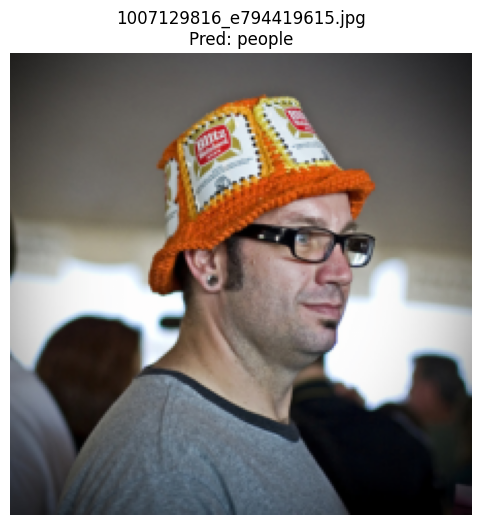

In [10]:
import os
import torch
import matplotlib.pyplot as plt
from torchvision import transforms

model = ImageCaptioningModel(vocab_size=len(vocab)).to(DEVICE)
if os.path.exists(save_path):
    try:
        model.load_state_dict(torch.load(save_path, map_location=DEVICE))
    except RuntimeError as e:
        print("Checkpoint is incompatible with current model. Re-run training cell to save new weights.")
        print(e)
else:
    print("No checkpoint found. Run training cell first.")

@torch.no_grad()
def generate_caption(model, image: torch.Tensor, max_len: int = 24) -> str:
    model.eval()
    image = image.unsqueeze(0).to(DEVICE)
    image_feats = model.encoder(image)

    tokens = [vocab["<BOS>"]]
    for _ in range(max_len - 1):
        caption_in = torch.tensor(tokens, dtype=torch.long, device=DEVICE).unsqueeze(0)
        logits, _ = model.decoder(image_feats, caption_in)
        next_token = int(torch.argmax(logits[0, -1]).item())
        tokens.append(next_token)
        if next_token == vocab["<EOS>"]:
            break

    return decode_ids(tokens)

inv_norm = transforms.Normalize(
    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
    std=[1 / 0.229, 1 / 0.224, 1 / 0.225],
)

image_tensor, _, image_name = dataset[4]
pred_caption = generate_caption(model, image_tensor, max_len=MAX_LEN)

show_img = inv_norm(image_tensor).clamp(0, 1).permute(1, 2, 0).cpu()
plt.figure(figsize=(6, 6))
plt.imshow(show_img)
plt.title(f"{image_name}\nPred: {pred_caption}")
plt.axis("off")
plt.show()